# Supervised Learning: USA BMI Extremes

This notebook tests whether a microbial signature distinguishes the **tails** of the USA BMI distribution (Lean: BMI < 22, Obese: BMI > 35). The three-way Normal/Overweight/Obese contrast (see `03_Tsne_USA.ipynb`) showed no t-SNE clusters, which is expected when the signal is small and distributed across many features rather than driving global ordination structure. Restricting to the BMI tails maximises effect size; supervised learning then identifies the species that drive the contrast.

## Pipeline

1. **Random Forest** with `StratifiedKFold(5)` and `class_weight='balanced'` — captures non-linear effects and species interactions.
2. **Feature importance**: Mean Decrease in Impurity (built-in) plus permutation importance averaged across folds. Permutation importance is the trustworthy metric — MDI is included for comparison and inherits known biases.
3. **Logistic Regression** (`LogisticRegressionCV` with L1 penalty) — linear validator. Only species linearly associated with the contrast survive the L1 shrinkage.
4. **Signature intersection**: species ranked top-20 by RF and assigned a non-zero LR coefficient are the high-confidence biomarkers.
5. **Metrics**: Balanced Accuracy, Macro-F1, Confusion Matrix.

## Data leakage prevention

All preprocessing steps (`VarianceThreshold`, `StandardScaler`) are encapsulated in `sklearn.pipeline.Pipeline` objects, so they are fit on the train fold only and applied to the test fold without ever seeing test data. Permutation importance is computed on the held-out test fold of each split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## Load the extreme-BMI subset

The filtered dataframe was created in `03_Tsne_USA.ipynb` and persisted as `07_extreme_bmi_data.csv`. Each row is a USA sample with BMI < 22 (Lean) or BMI > 35 (Obese).

In [2]:
df = pd.read_csv('../data/processed/07_extreme_bmi_data.csv')

# Features and binary target
features = [col for col in df.columns if col.startswith('msp')]
X = df[features]
y = df['BMI_Extreme'].map({'Lean': 0, 'Obese': 1})

print(f"Total samples: {len(df)}")
print(f"Features: {len(features)}")
print()
print('Class balance:')
print(df['BMI_Extreme'].value_counts())
print()
print('BioProject distribution per class (sanity check for batch effects):')
print(pd.crosstab(df['BioProject'], df['BMI_Extreme']))

Total samples: 142
Features: 596

Class balance:
BMI_Extreme
Lean     119
Obese     23
Name: count, dtype: int64

BioProject distribution per class (sanity check for batch effects):
BMI_Extreme  Lean  Obese
BioProject              
PRJEB12449      8      4
PRJEB28687     13      8
PRJNA268964     7      0
PRJNA379741    12      2
PRJNA48479     79      9


## Random Forest with StratifiedKFold

`VarianceThreshold` removes near-zero-variance features (fit inside the pipeline so it never sees the test fold). `class_weight='balanced'` corrects for the Lean/Obese imbalance. Five outer folds give five test-set predictions and five permutation importance estimates per feature.

In [4]:
rf_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.0001)),
    ('rf', RandomForestClassifier(
        n_estimators=200,          # 300 -> 200 is usually indistinguishable
        max_features='sqrt',
        class_weight='balanced',
        min_samples_leaf=2,        # mild regularization, also speeds up trees
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_metrics = []
perm_importances_per_fold = []
mdi_importances_per_fold = []
features_kept_per_fold = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)

    fold_metrics.append({
        'Fold': fold_idx,
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Macro-F1': f1_score(y_test, y_pred, average='macro'),
    })

    var_support = rf_pipeline.named_steps['var_filter'].get_support()
    fold_features = X.columns[var_support]
    features_kept_per_fold.append(set(fold_features))

    mdi_importances_per_fold.append(
        pd.Series(rf_pipeline.named_steps['rf'].feature_importances_, index=fold_features)
    )

    # Permutation importance: run on the fitted RF over the *filtered* matrix,
    # not the whole pipeline. Avoids re-running VarianceThreshold on every shuffle.
    X_test_filt = rf_pipeline.named_steps['var_filter'].transform(X_test)
    perm = permutation_importance(
        rf_pipeline.named_steps['rf'], X_test_filt, y_test,
        n_repeats=10,                 # 20 -> 10; with few samples the extra repeats add noise more than signal
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='balanced_accuracy',
    )
    # Map back to full feature space (dropped features get 0)
    full = pd.Series(0.0, index=X.columns)
    full.loc[fold_features] = perm.importances_mean
    perm_importances_per_fold.append(full)

fold_metrics_df = pd.DataFrame(fold_metrics)
print('Random Forest performance per fold:')
print(fold_metrics_df.round(4).to_string(index=False))
print()
print(f"Balanced Accuracy: {fold_metrics_df['Balanced Accuracy'].mean():.4f} "
      f"+/- {fold_metrics_df['Balanced Accuracy'].std()*2:.4f}")
print(f"Macro-F1:          {fold_metrics_df['Macro-F1'].mean():.4f} "
      f"+/- {fold_metrics_df['Macro-F1'].std()*2:.4f}")

Random Forest performance per fold:
 Fold  Balanced Accuracy  Macro-F1
    1               0.50    0.4528
    2               0.60    0.6282
    3               0.50    0.4510
    4               0.50    0.4615
    5               0.75    0.8133

Balanced Accuracy: 0.5700 +/- 0.2191
Macro-F1:          0.5614 +/- 0.3192


## Confusion matrix

Out-of-fold predictions across all five folds, so every sample contributes once.

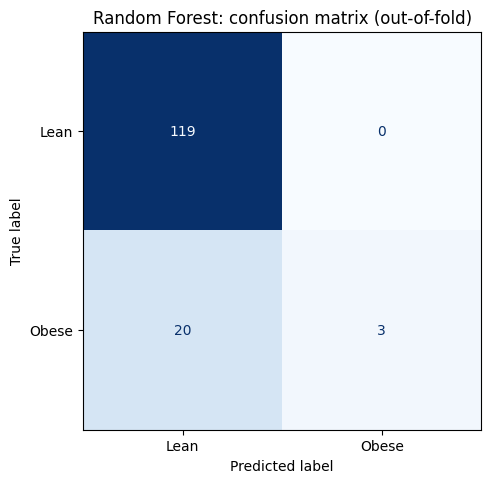

Out-of-fold balanced accuracy: 0.5652
Out-of-fold macro-F1:          0.5766


In [5]:
y_pred_oof = cross_val_predict(rf_pipeline, X, y, cv=cv, n_jobs=-1)

cm = confusion_matrix(y, y_pred_oof)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['Lean', 'Obese']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Random Forest: confusion matrix (out-of-fold)')
plt.tight_layout()
plt.show()

print(f"Out-of-fold balanced accuracy: {balanced_accuracy_score(y, y_pred_oof):.4f}")
print(f"Out-of-fold macro-F1:          {f1_score(y, y_pred_oof, average='macro'):.4f}")

## Feature importance: MDI vs. permutation

**Mean Decrease in Impurity (MDI)** is fast and built into the RF, but it is biased toward features with many possible split points (high-variance, continuous features) and is computed on the training data — features can look important simply because the RF used them, not because they generalise.

**Permutation importance** is computed on the held-out test fold by shuffling one feature at a time and measuring the drop in balanced accuracy. It directly answers "does this feature help the model on unseen data?" and is the metric to trust.

Both are averaged across the five folds. Features that were dropped by the variance filter in a given fold contribute 0 to that fold's importance.

/var/folders/1s/8c57rh4103jc16qhmyw2g4t40000gn/T/ipykernel_47173/1680301415.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mdi.values, y=top_mdi.index, palette='viridis', ax=axes[0])
/var/folders/1s/8c57rh4103jc16qhmyw2g4t40000gn/T/ipykernel_47173/1680301415.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_perm.values, y=top_perm.index, palette='viridis', ax=axes[1])


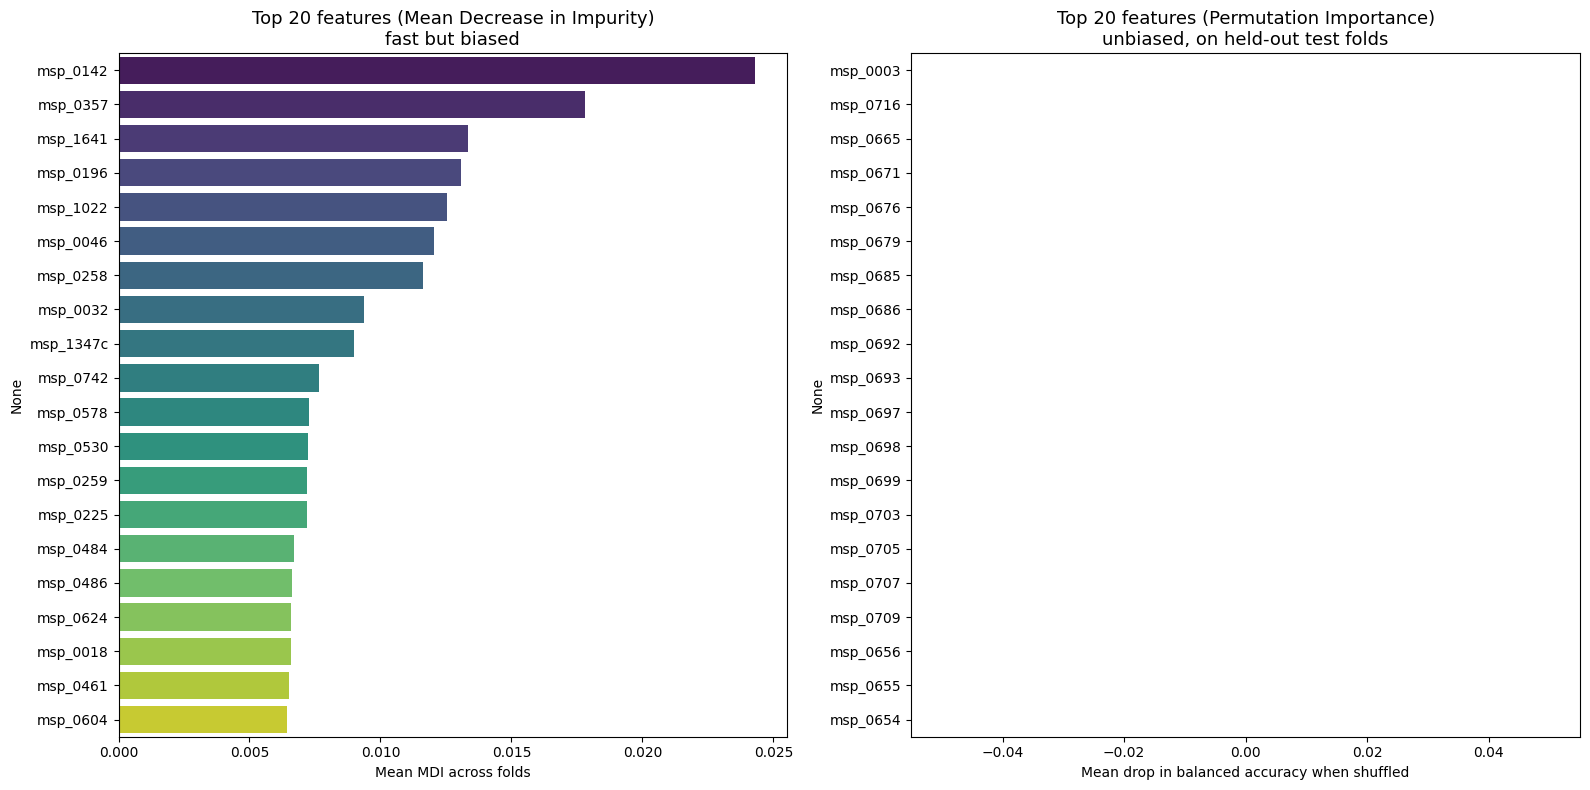

In [6]:
# Average MDI across folds (features missing from a fold get 0)
mdi_df = pd.concat(mdi_importances_per_fold, axis=1).fillna(0)
mdi_mean = mdi_df.mean(axis=1).sort_values(ascending=False)

# Average permutation importance across folds
perm_df = pd.concat(perm_importances_per_fold, axis=1).fillna(0)
perm_mean = perm_df.mean(axis=1).sort_values(ascending=False)

TOP_N = 20
top_mdi = mdi_mean.head(TOP_N)
top_perm = perm_mean.head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x=top_mdi.values, y=top_mdi.index, palette='viridis', ax=axes[0])
axes[0].set_title(f'Top {TOP_N} features (Mean Decrease in Impurity)\nfast but biased', fontsize=13)
axes[0].set_xlabel('Mean MDI across folds')

sns.barplot(x=top_perm.values, y=top_perm.index, palette='viridis', ax=axes[1])
axes[1].set_title(f'Top {TOP_N} features (Permutation Importance)\nunbiased, on held-out test folds', fontsize=13)
axes[1].set_xlabel('Mean drop in balanced accuracy when shuffled')

plt.tight_layout()
plt.show()

## Logistic Regression (L1) validation

`LogisticRegressionCV` automatically selects the regularization strength `C` by internal CV. The L1 penalty drives weak coefficients to exactly zero, so the surviving non-zero features form a sparse linear signature.

Same outer `StratifiedKFold` is used for performance estimation. The pipeline includes `StandardScaler` because LR coefficients are scale-sensitive.

In [7]:
lr_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.0001)),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty='l1',
        solver='saga',
        scoring='balanced_accuracy',
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lr_fold_metrics = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lr_pipeline.fit(X_train, y_train)
    y_pred = lr_pipeline.predict(X_test)

    lr_fold_metrics.append({
        'Fold': fold_idx,
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Macro-F1': f1_score(y_test, y_pred, average='macro'),
    })

lr_fold_metrics_df = pd.DataFrame(lr_fold_metrics)
print('Logistic Regression (L1) performance per fold:')
print(lr_fold_metrics_df.round(4).to_string(index=False))
print()
print(f"Balanced Accuracy: {lr_fold_metrics_df['Balanced Accuracy'].mean():.4f} "
      f"+/- {lr_fold_metrics_df['Balanced Accuracy'].std()*2:.4f}")
print(f"Macro-F1:          {lr_fold_metrics_df['Macro-F1'].mean():.4f} "
      f"+/- {lr_fold_metrics_df['Macro-F1'].std()*2:.4f}")

/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-le

Logistic Regression (L1) performance per fold:
 Fold  Balanced Accuracy  Macro-F1
    1             0.5375    0.5397
    2             0.7583    0.7583
    3             0.5565    0.5625
    4             0.6875    0.6690
    5             0.9375    0.8303

Balanced Accuracy: 0.6955 +/- 0.3269
Macro-F1:          0.6720 +/- 0.2490


/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-le

L1 LR retained 596 non-zero features (out of 596 after variance filter)



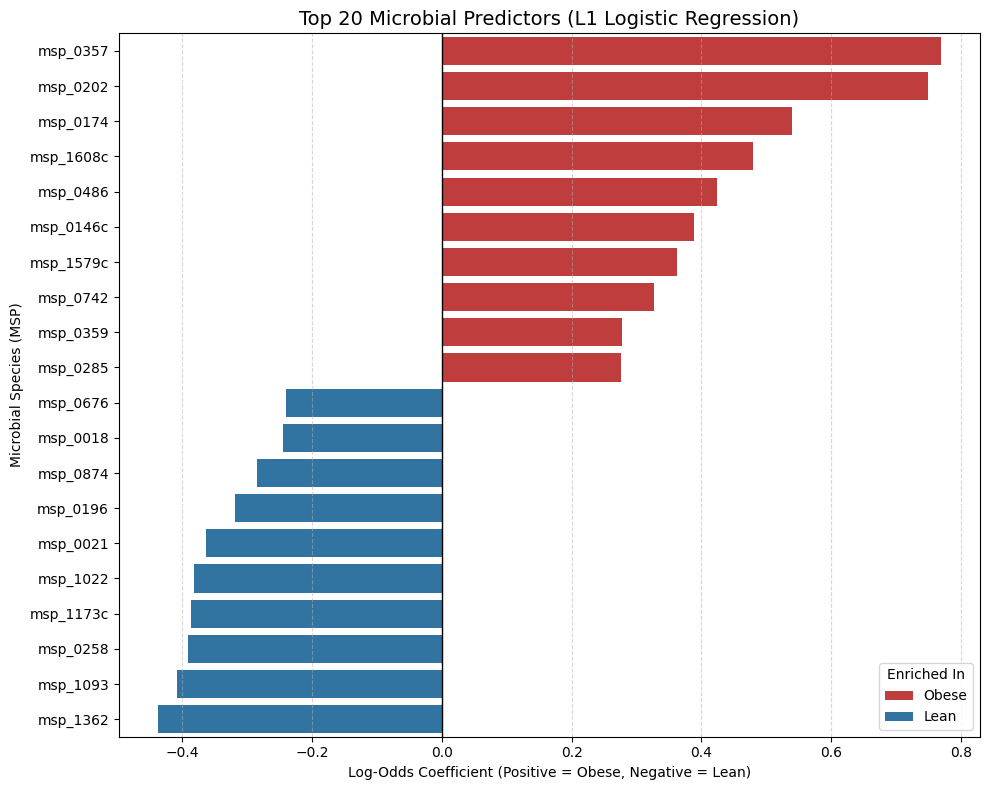

In [8]:
# Refit LR on full data to extract the final non-zero coefficients
lr_pipeline.fit(X, y)
var_support = lr_pipeline.named_steps['var_filter'].get_support()
features_after_var = X.columns[var_support]
coefficients = lr_pipeline.named_steps['lr'].coef_[0]

lr_coef_df = pd.DataFrame({
    'Microbe': features_after_var,
    'Coefficient': coefficients
})
lr_coef_df = lr_coef_df[lr_coef_df['Coefficient'] != 0].copy()
lr_coef_df['Abs_Coef'] = lr_coef_df['Coefficient'].abs()
lr_coef_df['Enriched_In'] = np.where(lr_coef_df['Coefficient'] > 0, 'Obese', 'Lean')
lr_coef_df = lr_coef_df.sort_values(by='Abs_Coef', ascending=False).reset_index(drop=True)

print(f"L1 LR retained {len(lr_coef_df)} non-zero features (out of {len(features_after_var)} after variance filter)")
print()
top_lr_plot = lr_coef_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_lr_plot.sort_values(by='Coefficient', ascending=False),
    x='Coefficient', y='Microbe',
    hue='Enriched_In',
    palette={'Obese': '#d62728', 'Lean': '#1f77b4'},
    dodge=False
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 20 Microbial Predictors (L1 Logistic Regression)', fontsize=14)
plt.xlabel('Log-Odds Coefficient (Positive = Obese, Negative = Lean)')
plt.ylabel('Microbial Species (MSP)')
plt.legend(title='Enriched In', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## High-confidence signature: RF ∩ LR intersection

Species that appear in **both** the RF top-20 (by permutation importance) and the L1 LR non-zero coefficients are the most robust biomarkers — they are non-linearly *and* linearly associated with the BMI extreme contrast. We also annotate each species with its enrichment direction (Lean vs. Obese) from the LR coefficient sign and check whether the two models agree on the direction.

In [9]:
# RF top-20 by permutation importance
rf_top_set = set(top_perm.index)

# LR non-zero features
lr_nonzero_set = set(lr_coef_df['Microbe'])

intersection = sorted(rf_top_set & lr_nonzero_set)
print(f"Intersection size: {len(intersection)} species")
print()

# Build the consensus table.
# RF direction: sign of (mean abundance in Obese - mean abundance in Lean) using CLR values.
# A positive difference means the species is higher in Obese samples.
mean_lean = X[y == 0].mean()
mean_obese = X[y == 1].mean()
rf_direction = pd.Series(
    np.where(mean_obese - mean_lean > 0, 'Obese', 'Lean'),
    index=X.columns
)

lr_direction = dict(zip(lr_coef_df['Microbe'], lr_coef_df['Enriched_In']))

rows = []
for microbe in intersection:
    rf_dir = rf_direction[microbe]
    lr_dir = lr_direction[microbe]
    rows.append({
        'Microbe': microbe,
        'RF_Permutation_Importance': perm_mean[microbe],
        'LR_Coefficient': lr_coef_df.set_index('Microbe').loc[microbe, 'Coefficient'],
        'RF_Direction': rf_dir,
        'LR_Direction': lr_dir,
        'Agreement': 'AGREE' if rf_dir == lr_dir else 'DISAGREE'
    })

consensus_df = (
    pd.DataFrame(rows)
    .sort_values('RF_Permutation_Importance', ascending=False)
    .reset_index(drop=True)
)

print(consensus_df.to_string(
    index=False,
    formatters={
        'RF_Permutation_Importance': '{:.4f}'.format,
        'LR_Coefficient': '{:+.4f}'.format,
    }
))
print()
print(f"AGREE:    {(consensus_df['Agreement'] == 'AGREE').sum()} species")
print(f"DISAGREE: {(consensus_df['Agreement'] == 'DISAGREE').sum()} species")

Intersection size: 20 species

 Microbe RF_Permutation_Importance LR_Coefficient RF_Direction LR_Direction Agreement
msp_0003                    0.0000        -0.0391         Lean         Lean     AGREE
msp_0654                    0.0000        +0.0117        Obese        Obese     AGREE
msp_0709                    0.0000        -0.1700         Lean         Lean     AGREE
msp_0707                    0.0000        +0.0586        Obese        Obese     AGREE
msp_0705                    0.0000        +0.0056        Obese        Obese     AGREE
msp_0703                    0.0000        -0.0062         Lean         Lean     AGREE
msp_0699                    0.0000        +0.0182         Lean        Obese  DISAGREE
msp_0698                    0.0000        -0.0881         Lean         Lean     AGREE
msp_0697                    0.0000        -0.1110         Lean         Lean     AGREE
msp_0693                    0.0000        -0.0209        Obese         Lean  DISAGREE
msp_0692               

In [ ]:
# Persist all three result tables
rf_results_df = pd.DataFrame({
    'Microbe': perm_mean.index,
    'Permutation_Importance': perm_mean.values,
    'MDI_Importance': mdi_mean.reindex(perm_mean.index).values,
}).head(20)
rf_results_df.to_csv('../results/biomarker_table_rf_bmi_extremes.csv', index=False)

lr_coef_df.drop(columns='Abs_Coef').to_csv(
    '../results/biomarker_table_lr_bmi_extremes.csv', index=False
)

consensus_df.to_csv('../results/biomarker_consensus_bmi_extremes.csv', index=False)

print('Saved:')
print('  ../results/biomarker_table_rf_bmi_extremes.csv')
print('  ../results/biomarker_table_lr_bmi_extremes.csv')
print('  ../results/biomarker_consensus_bmi_extremes.csv')

## Interpretation guide

A few notes for reading the results:

*   **If balanced accuracy is close to 0.5** (~chance), the BMI tail signal in the gut microbiome of this cohort is below the detection limit at this sample size. The intersection table is then noise and should not be reported as biomarkers without external replication.
*   **If balanced accuracy is in the 0.6 – 0.75 range**, the signal is real but moderate, which is typical for within-population microbiome × phenotype contrasts. Top intersection species are publishable as candidates pending validation.
*   **DISAGREE rows** in the consensus table indicate non-linear or interaction-driven effects that LR cannot capture by sign alone — interesting but interpret with caution.
*   The **MDI vs. permutation importance plots** should overlap substantially in their top features. Large divergence usually means MDI is being misled by feature variance rather than true predictive value, and permutation importance is the one to trust.